In [306]:
import pandas as pd
import time
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.combine import SMOTETomek

In [307]:
data_path = "early_wakeup_health_dataset.csv"

df = pd.read_csv(data_path)

df.head(10)

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No
5,P00006,79,Male,166.2,60.5,21.90,India,Accountant,Married,07:50,...,Low,High,Medium,High,Medium,60.6,Average,52.0,Average,No
6,P00007,74,Male,169.9,55.0,19.06,Canada,Software Engineer,Single,06:49,...,Low,High,Medium,Medium,Low,72.3,Good,66.7,Good,No
7,P00008,67,Female,160.8,82.5,31.91,Brazil,Retired,Single,06:11,...,High,High,Medium,Medium,Medium,46.7,Average,39.6,Average,Yes
8,P00009,22,Male,190.8,65.1,17.88,UK,Software Engineer,Single,06:54,...,Low,Low,Low,Low,Low,78.8,Good,90.2,Good,No
9,P00010,22,Male,177.9,90.7,28.67,Italy,Software Engineer,Single,07:06,...,Medium,High,Low,Low,Medium,70.0,Good,76.8,Good,No


In [308]:
# Reading Missing Values
print(f"Readning Null : {df.isnull().sum().max()}")

Readning Null : 3014


Exercise_Type           824
Workout_Intensity       824
Alcohol_Consumption    3014
dtype: int64


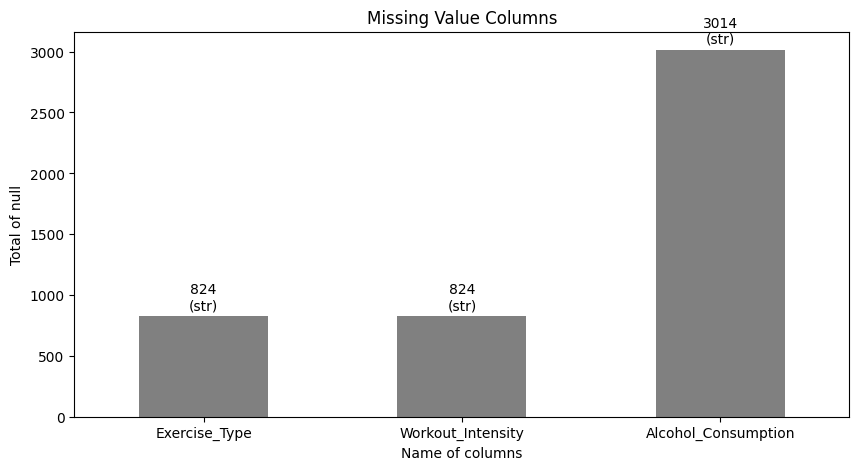

In [309]:
# Searching for null fields

missing_value = df.isnull().sum()[df.isnull().sum() > 0]

missing_types = df[missing_value.index].dtypes

print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10,5))

ax = missing_value.plot.bar(color='gray')

for i, col in enumerate(missing_value.index):
    count = missing_value[col]
    dtype = missing_types[col]

    ax.text(i, count + (max(missing_value) * 0.01), f"{count}\n({dtype})", ha='center', va='bottom')

plt.title("Missing Value Columns")
plt.xlabel("Name of columns")
plt.ylabel("Total of null")
plt.xticks(rotation=0)
plt.show()

In [310]:
dfe = df.copy()

dfe = dfe.drop(['Person_ID'], axis=1)

cat_cols = ['Exercise_Type', 'Workout_Intensity', 'Alcohol_Consumption']    # Text data ('Moderate', 'Weight Training')

cat_imputer = SimpleImputer(strategy='most_frequent')
dfe[cat_cols] = cat_imputer.fit_transform(dfe[cat_cols])

print(f"Missing Values : {dfe.isnull().sum().max()}")



Missing Values : 0


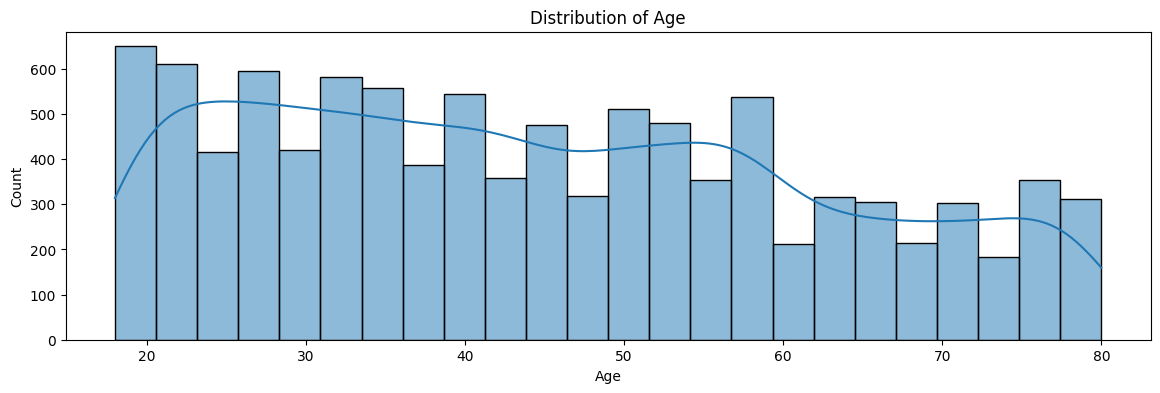

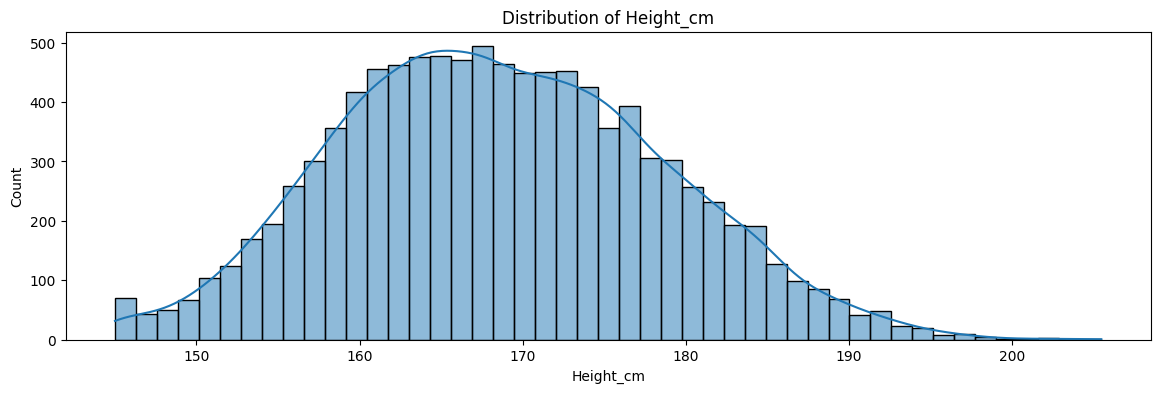

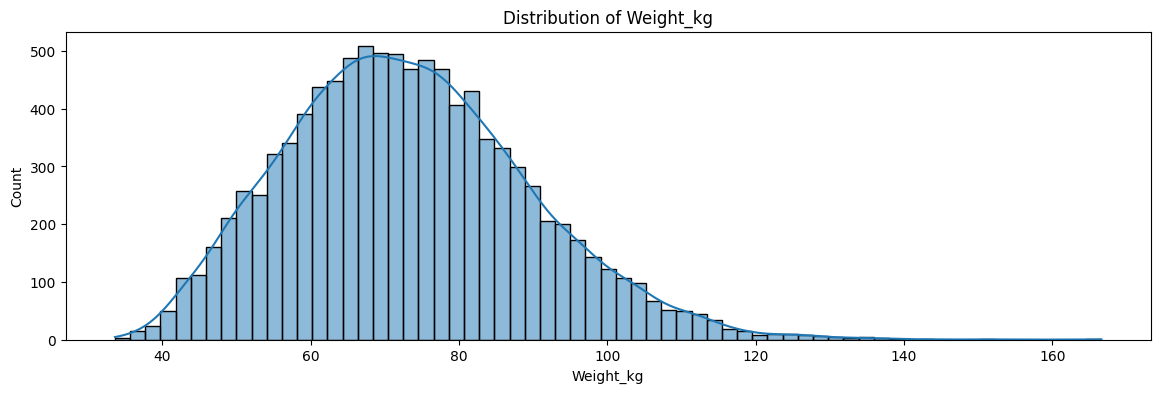

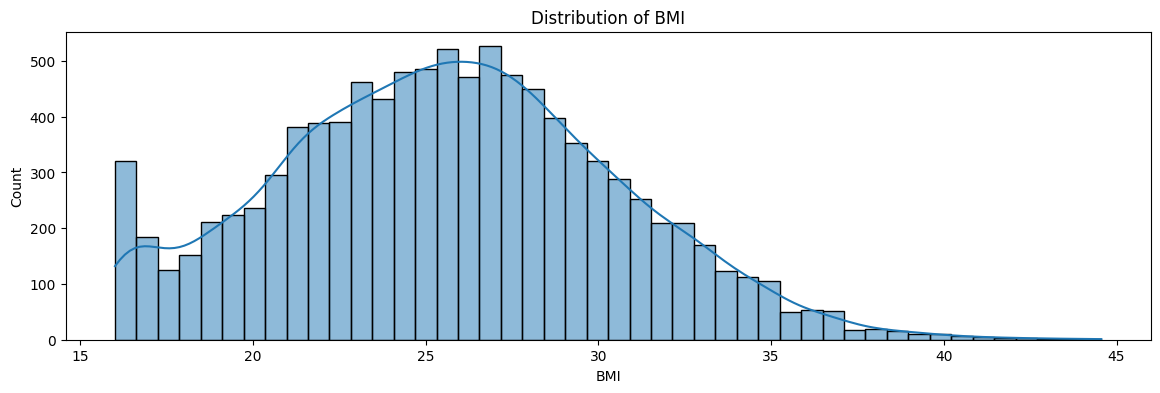

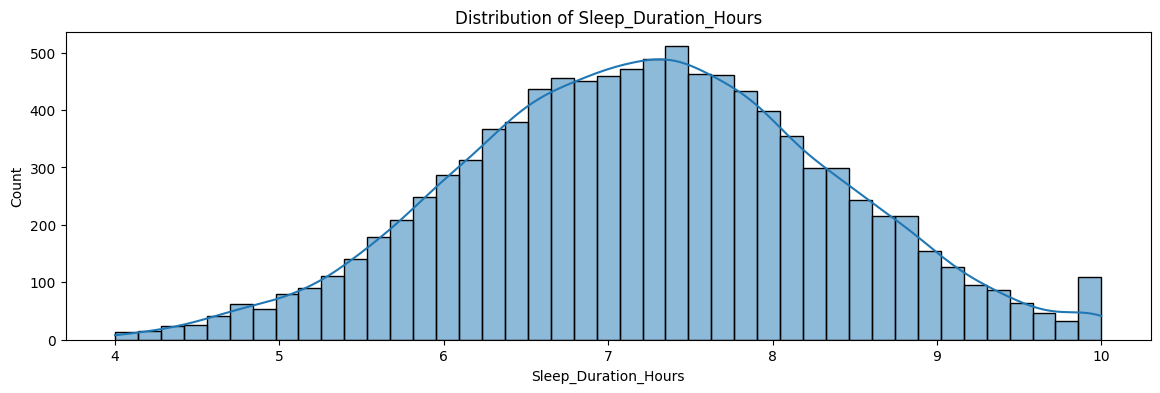

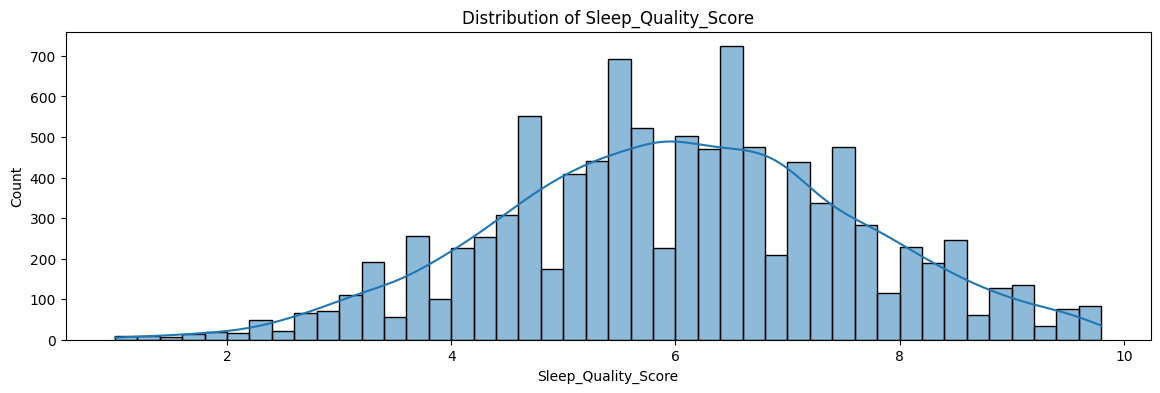

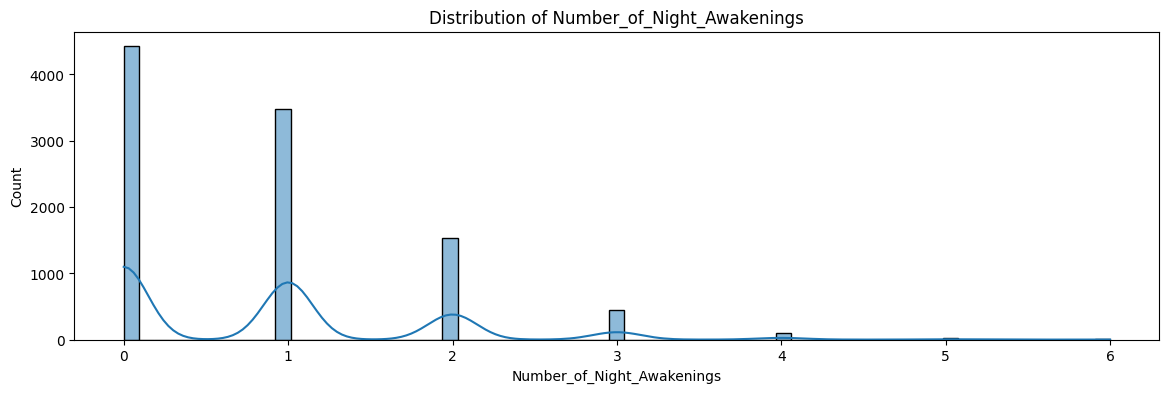

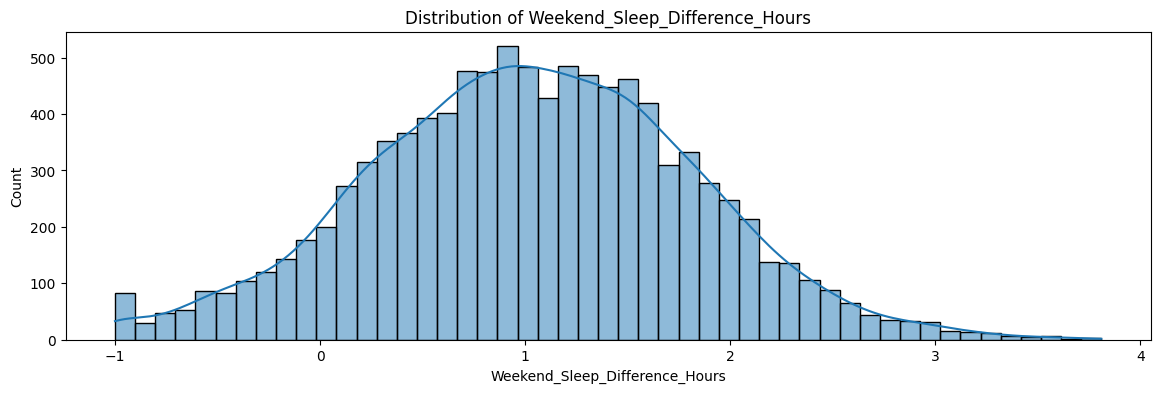

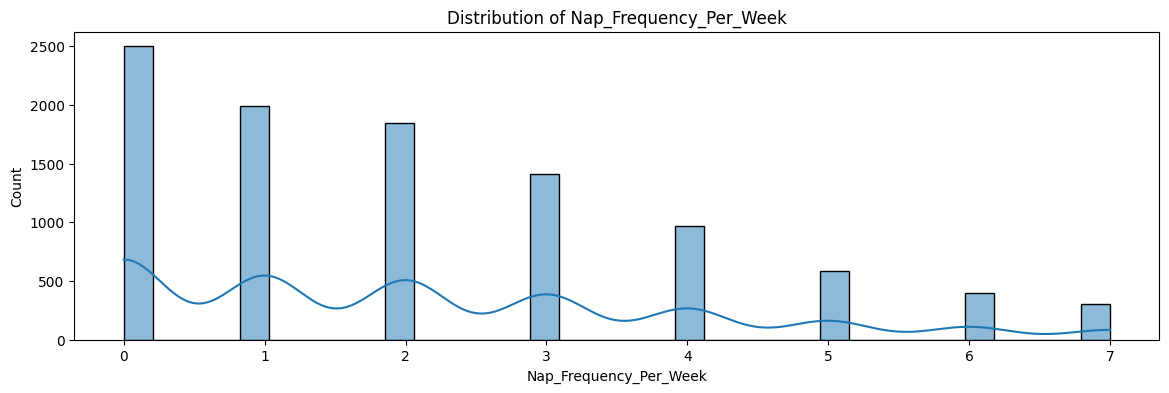

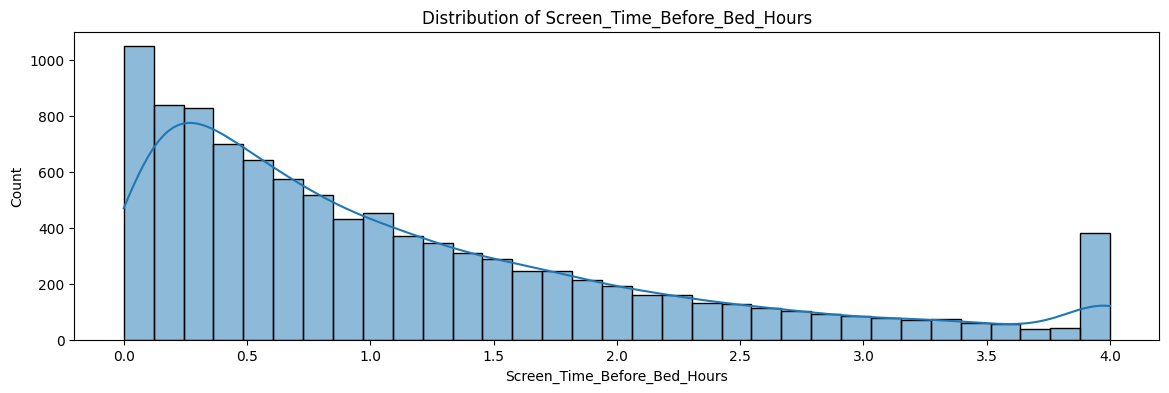

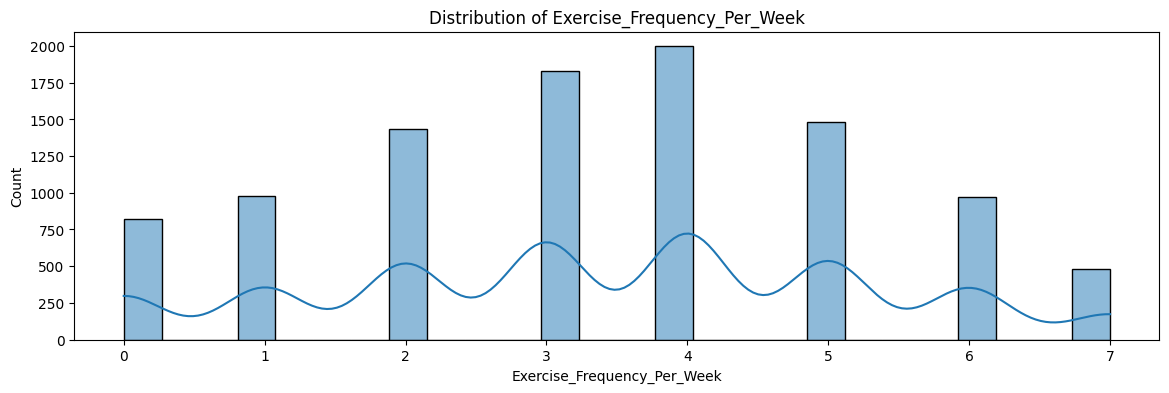

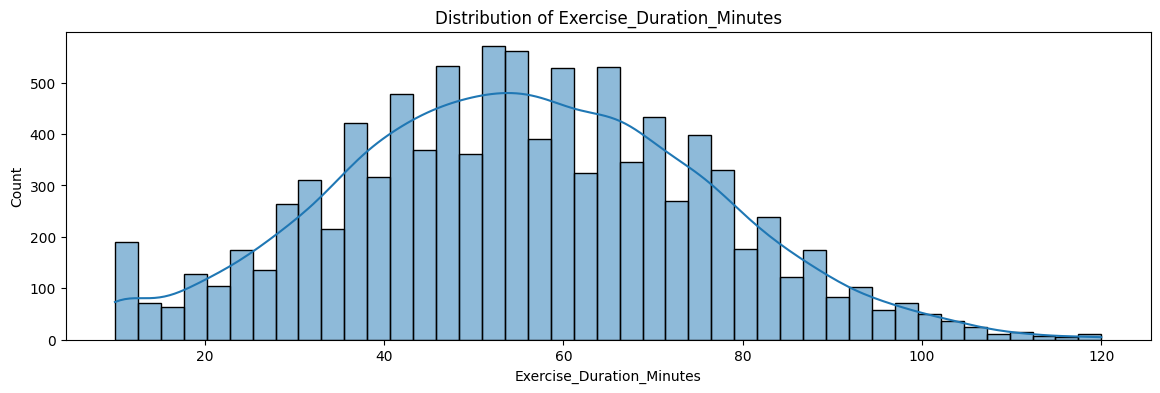

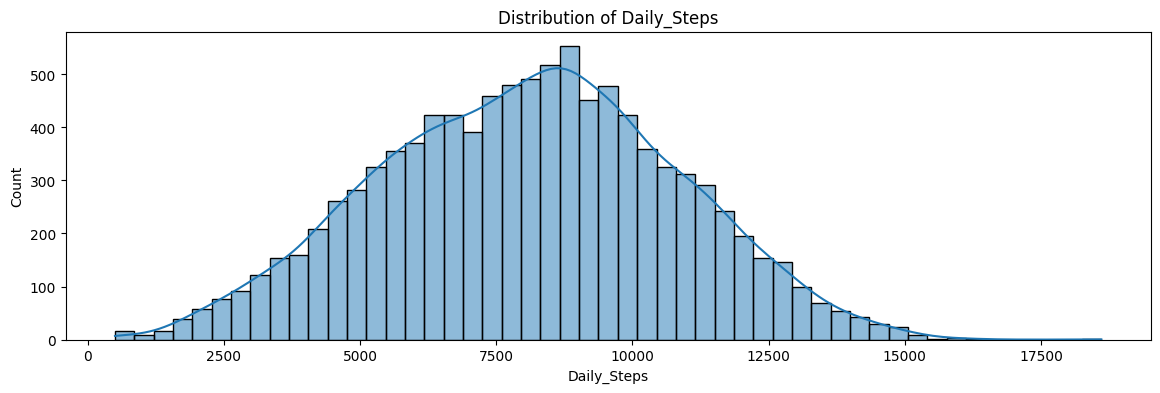

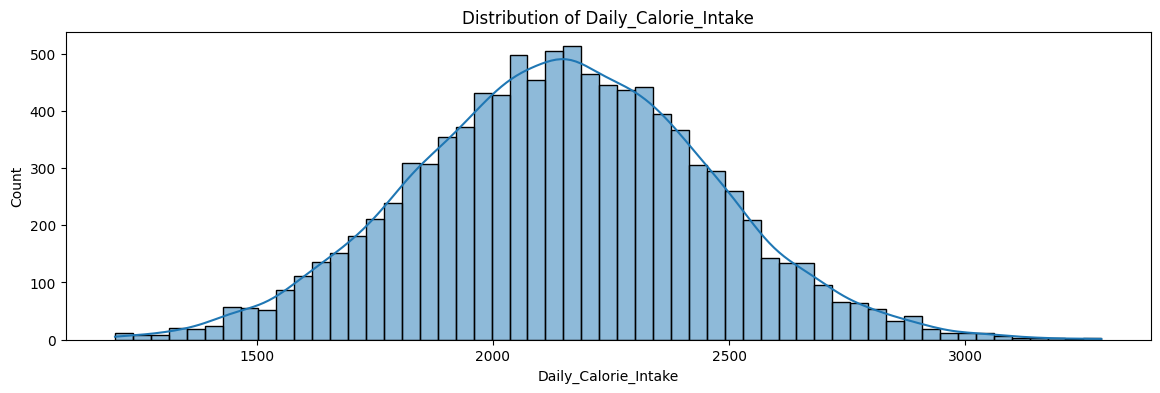

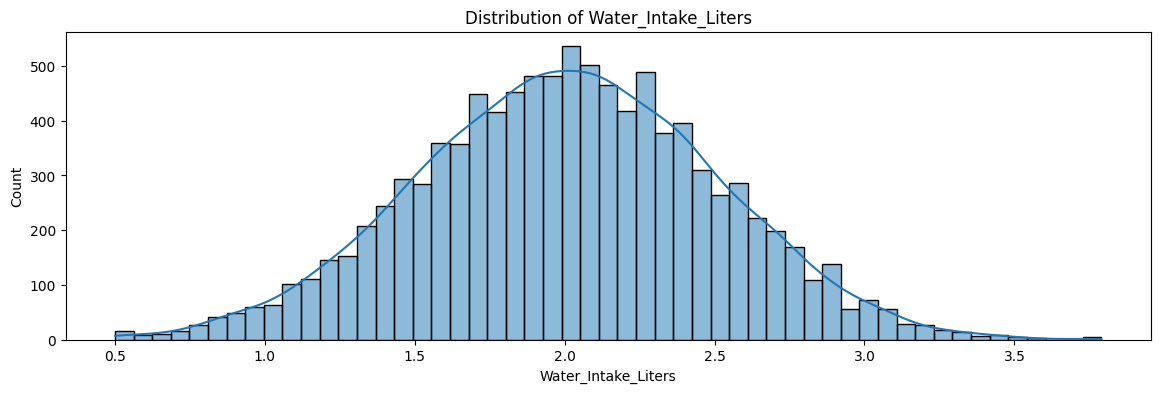

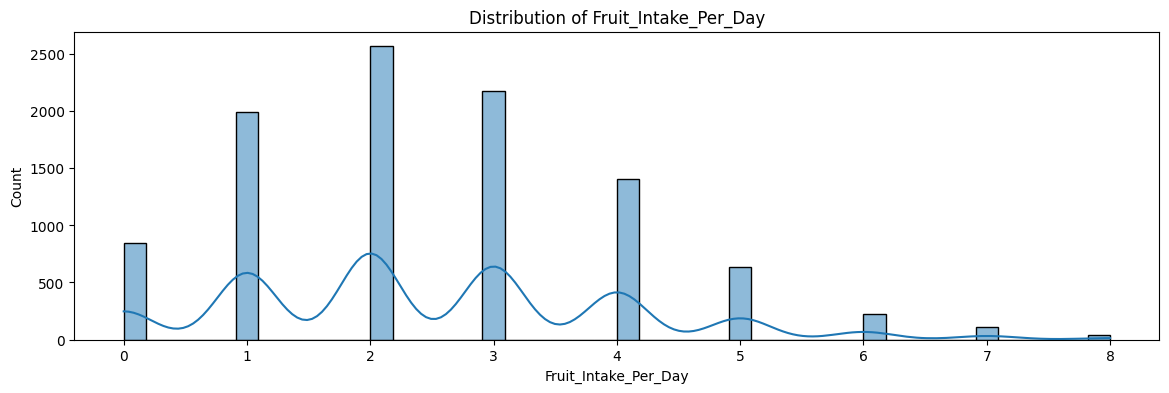

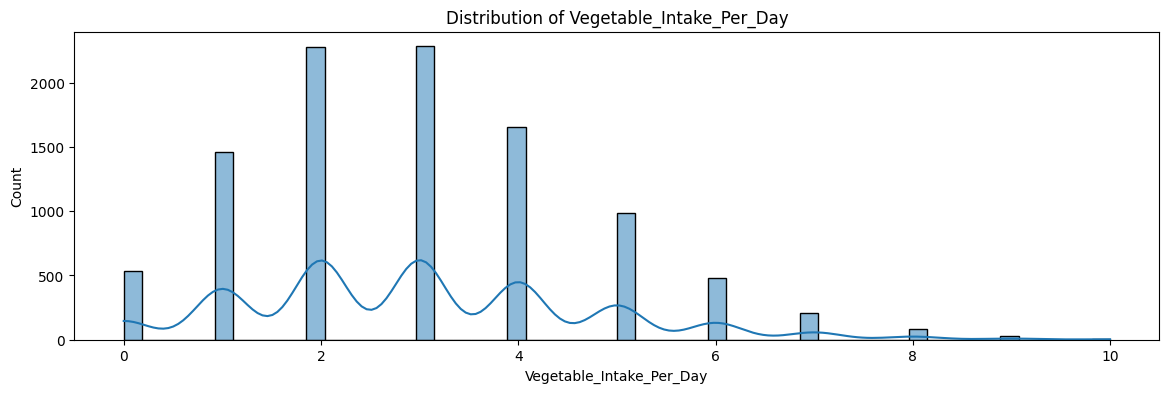

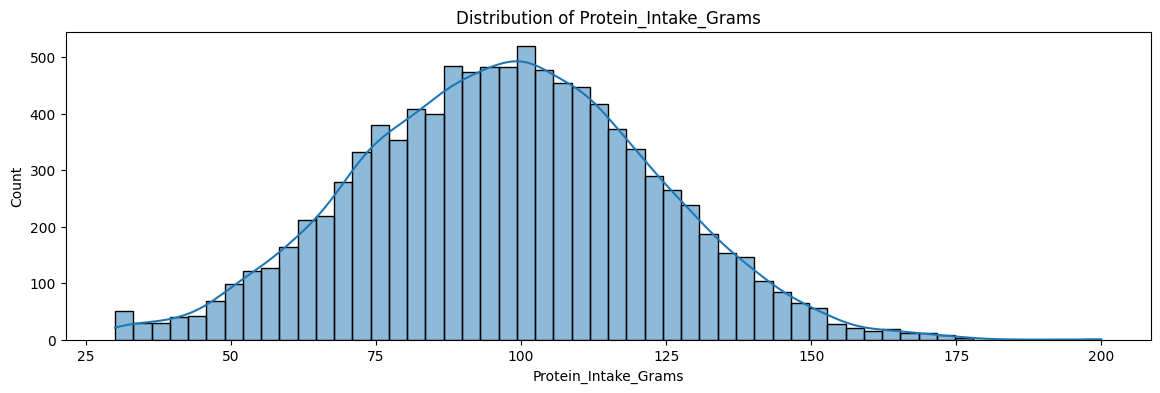

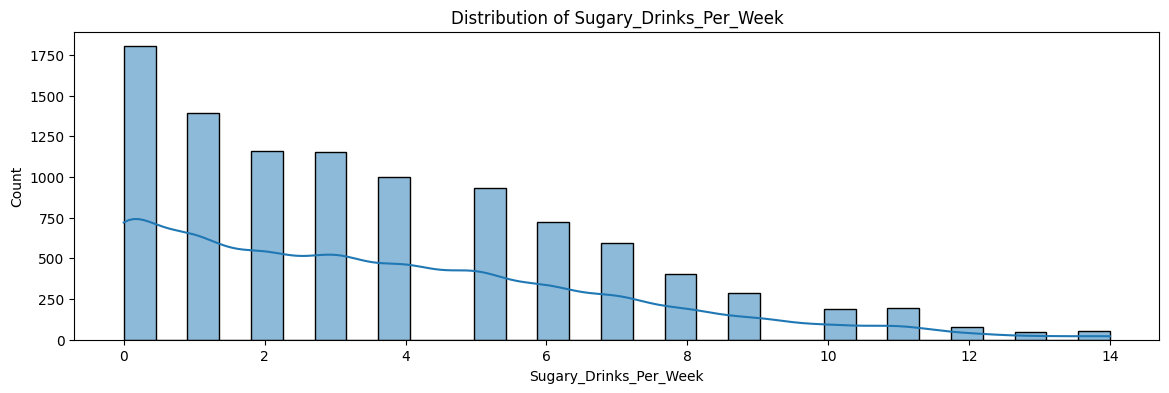

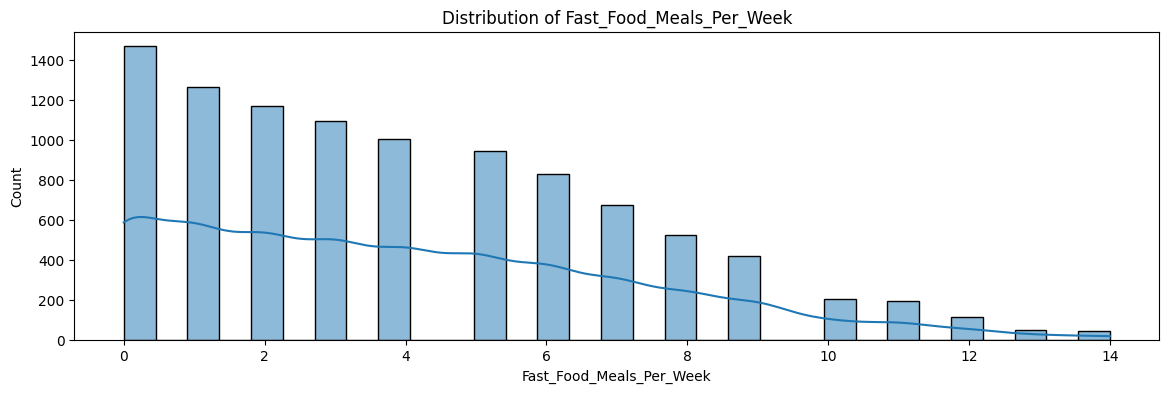

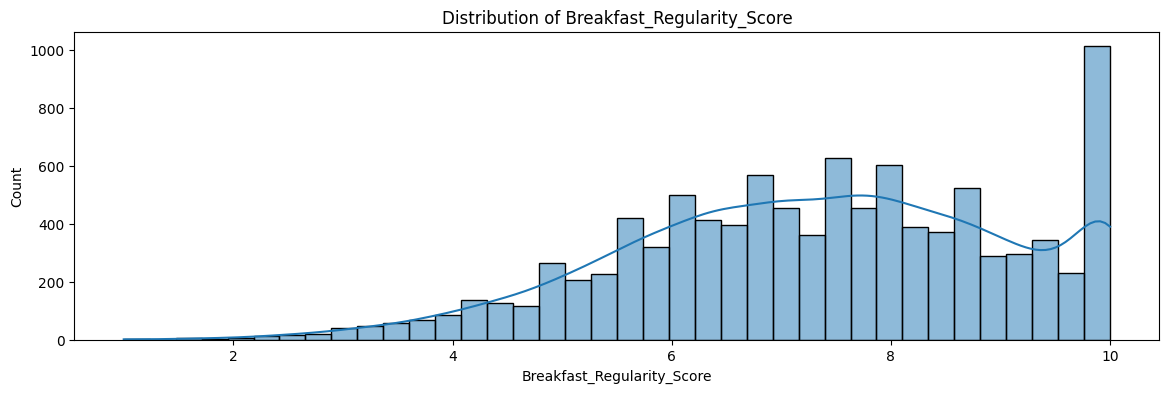

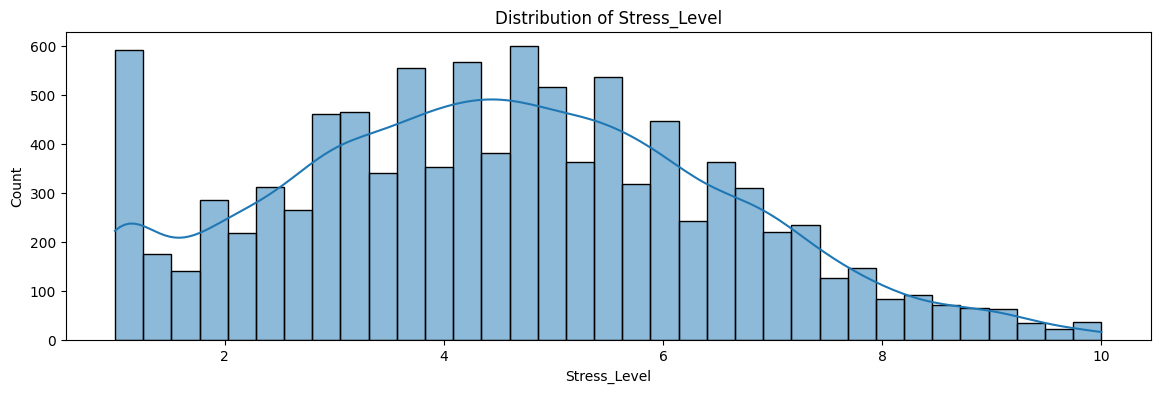

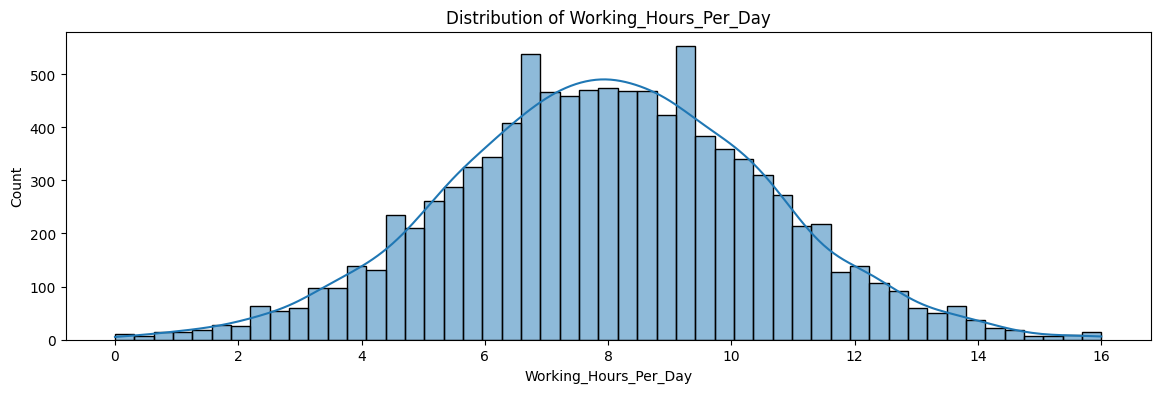

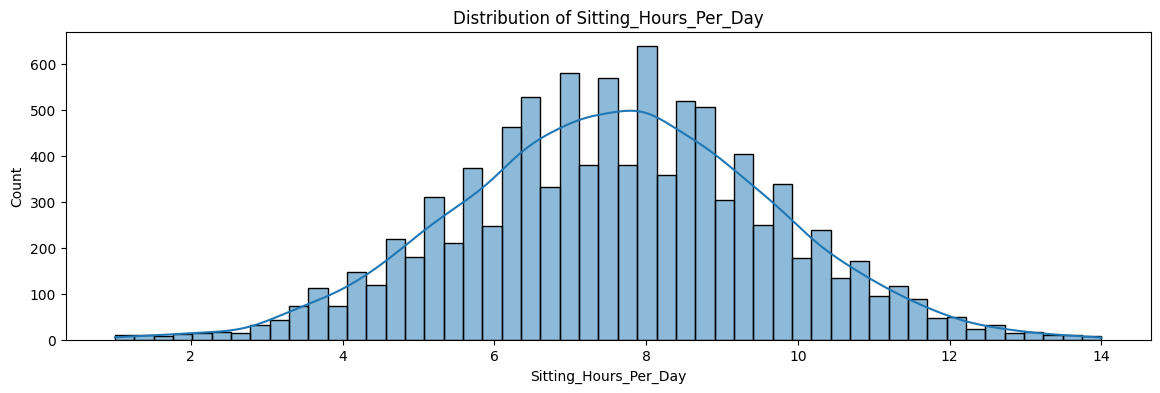

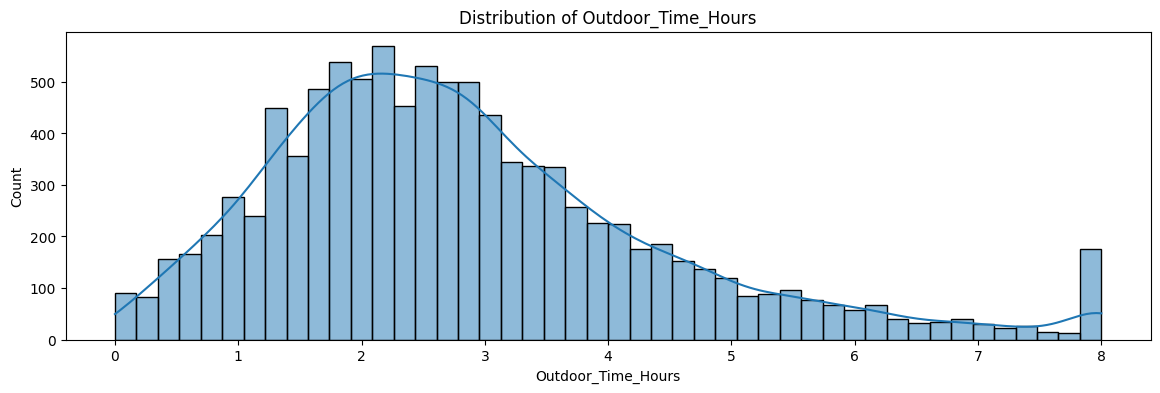

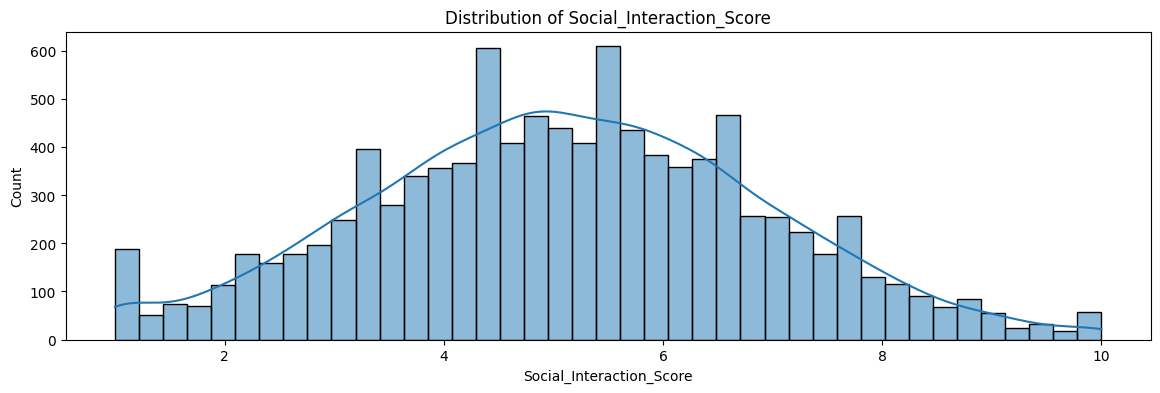

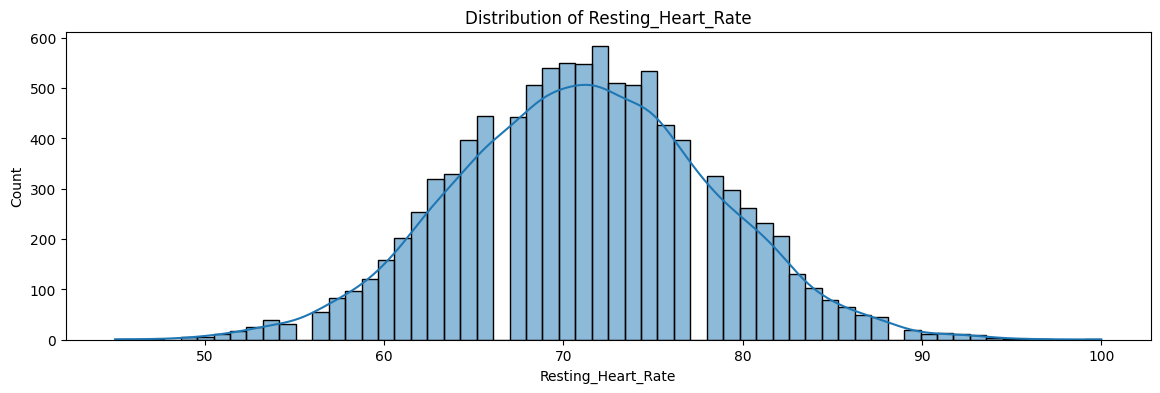

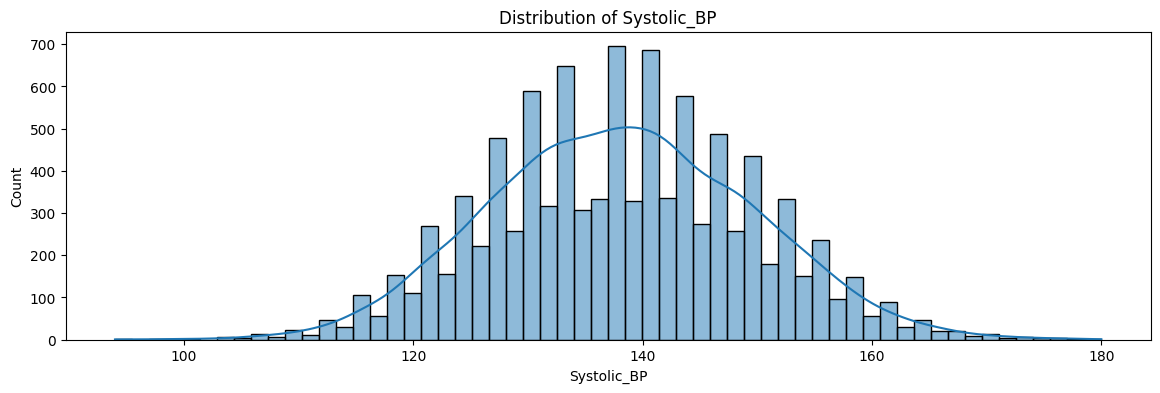

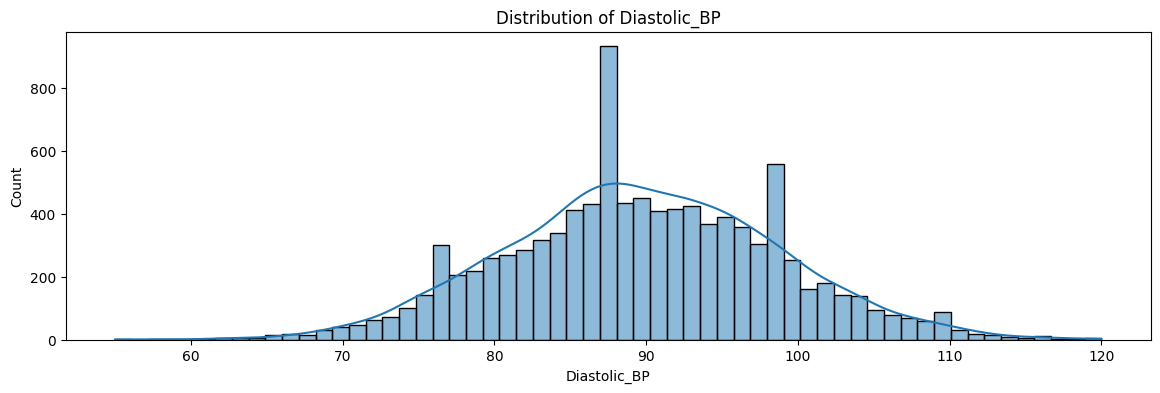

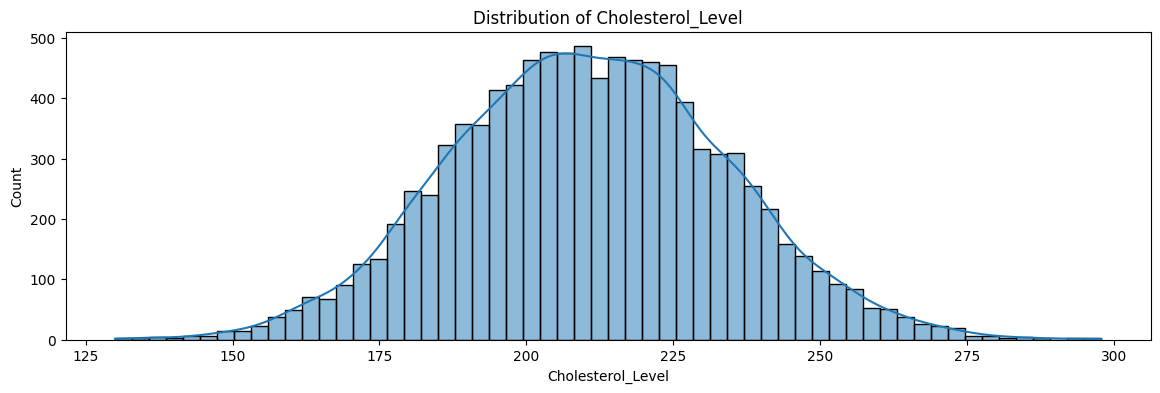

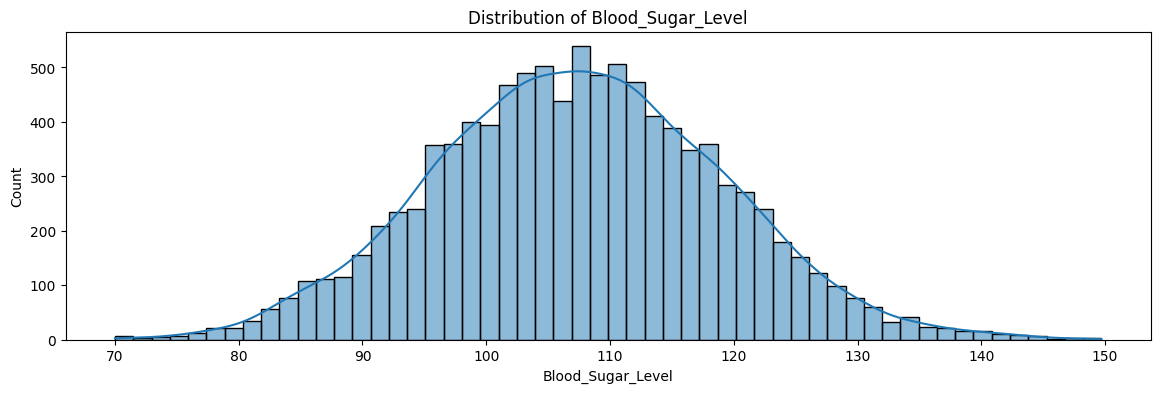

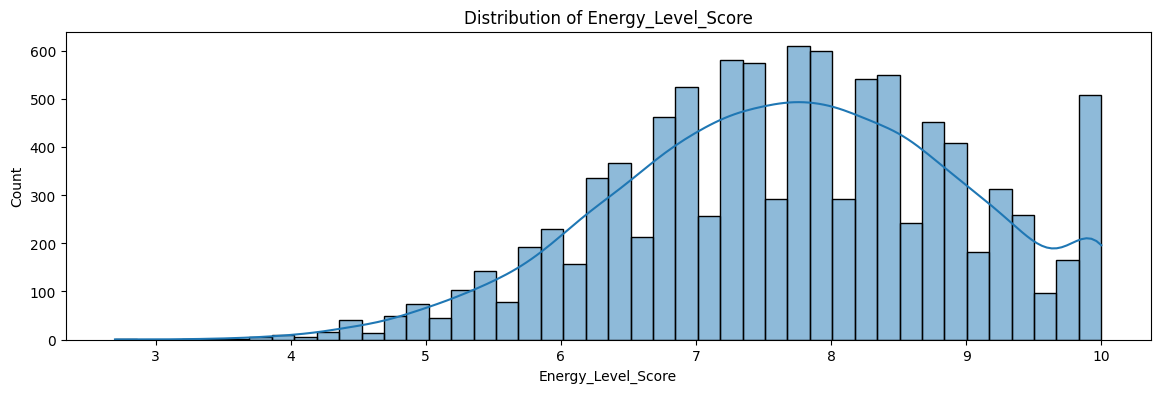

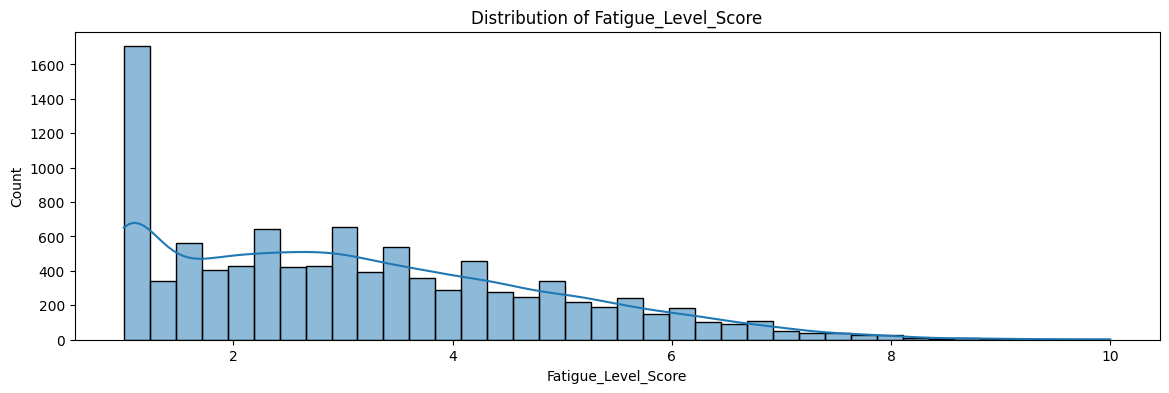

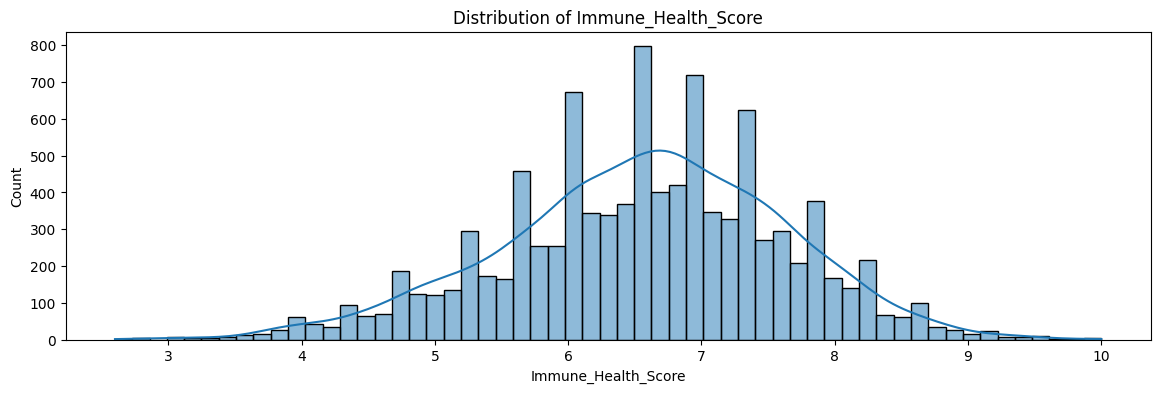

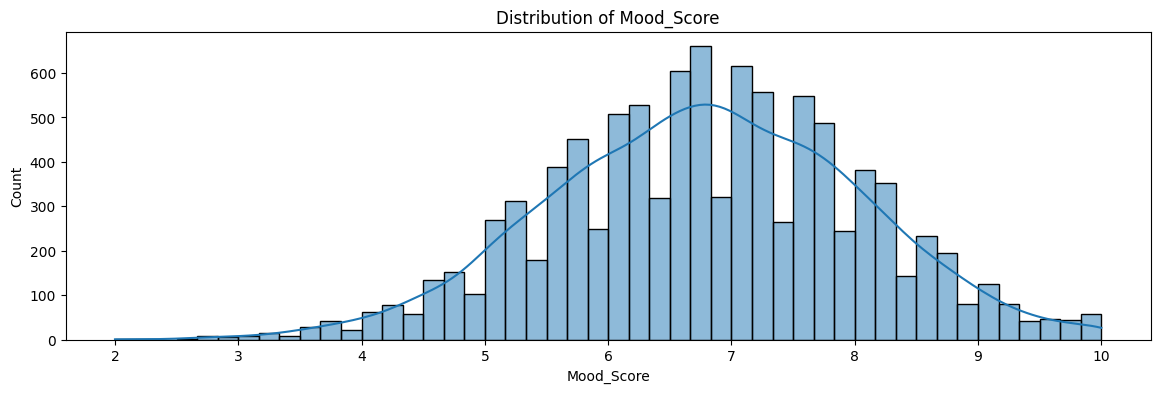

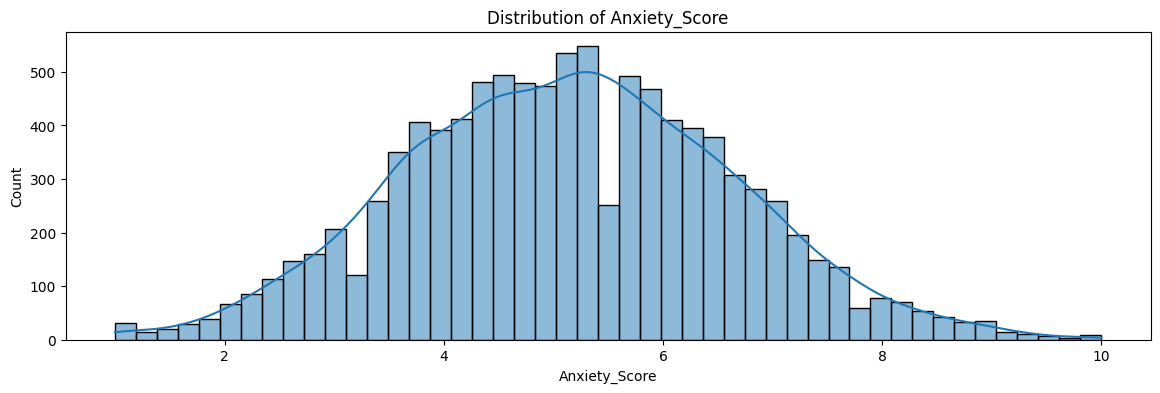

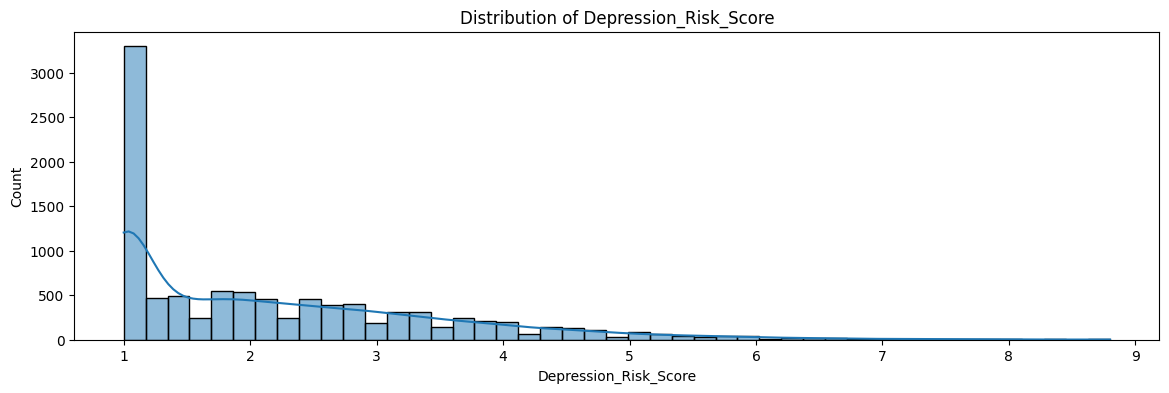

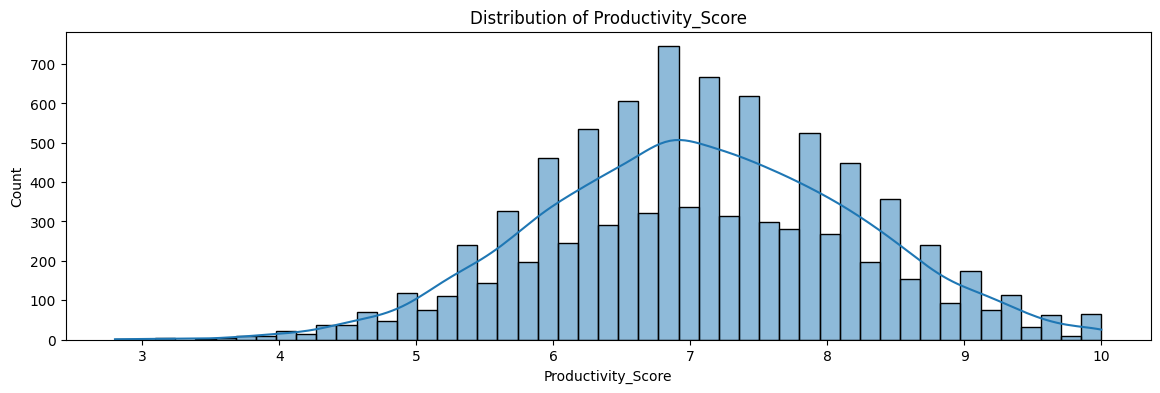

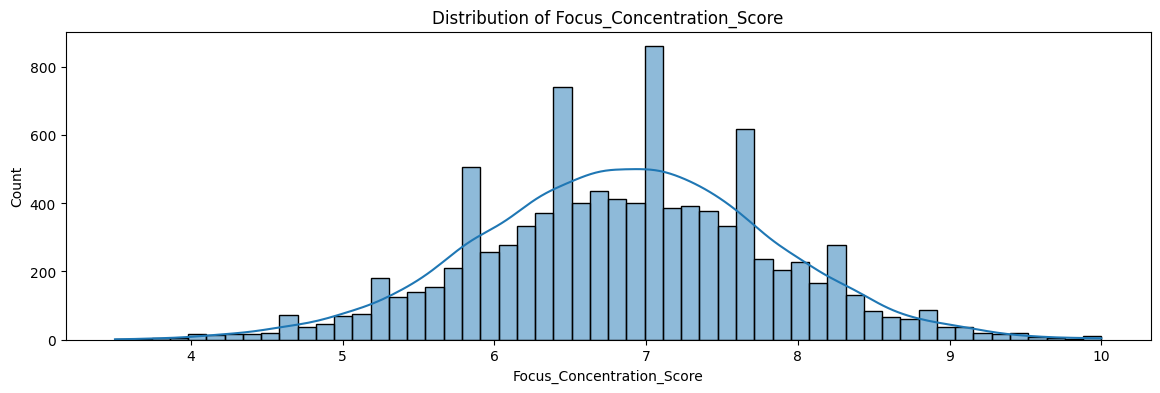

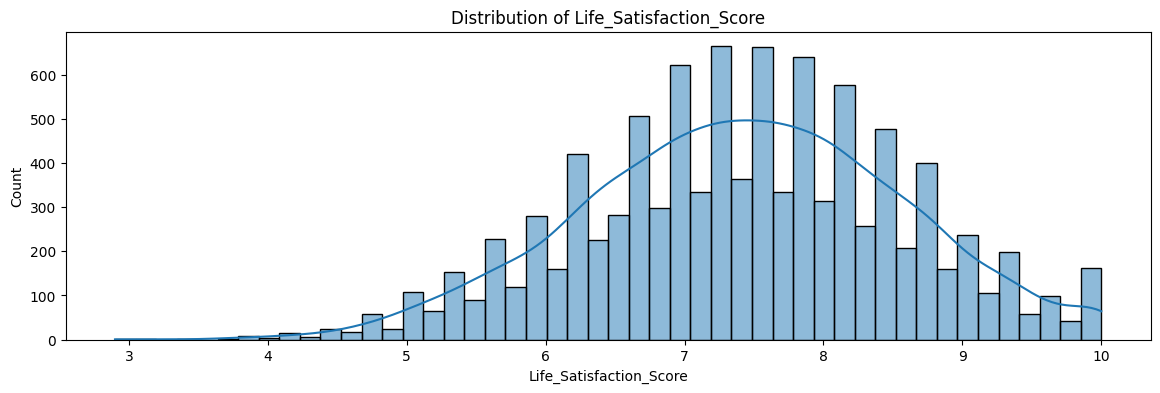

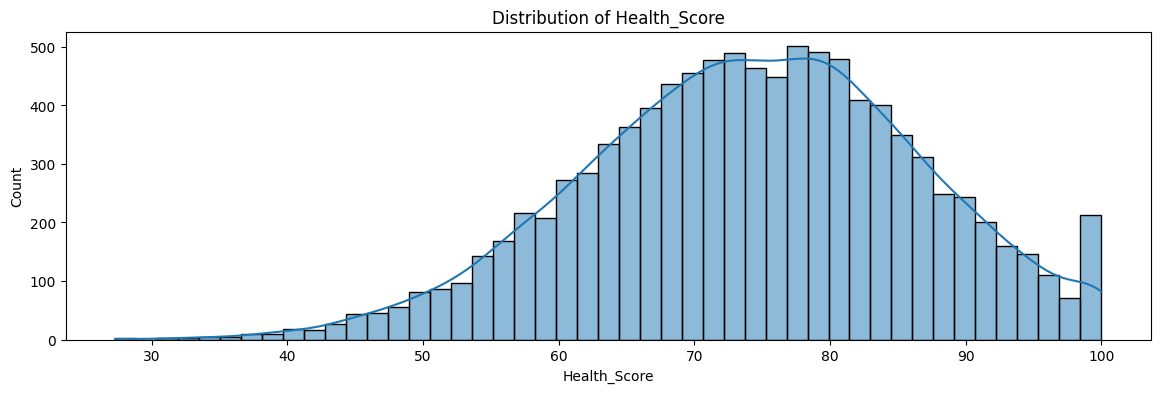

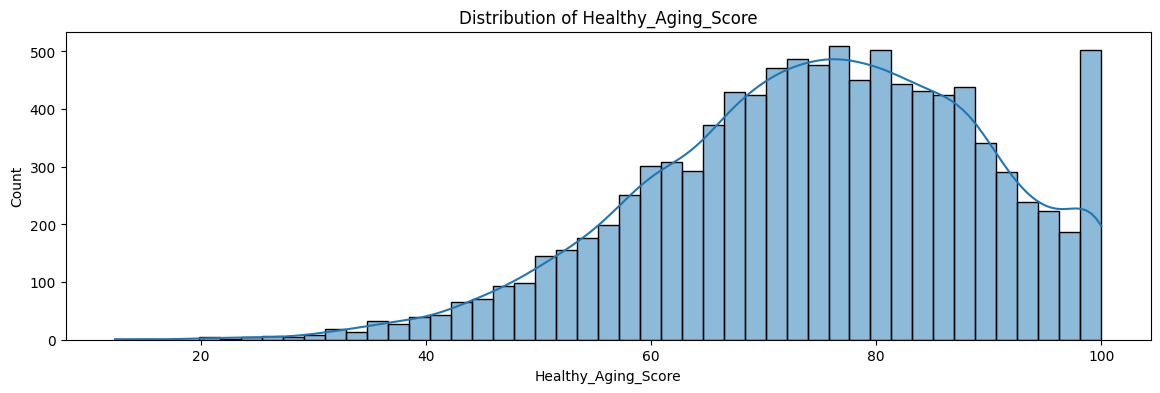

In [311]:
num_cols=dfe.select_dtypes(include='number')
for col in num_cols[:10]:
    plt.figure(figsize=(14,4))
    sns.histplot(dfe[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [312]:
col_uni = dfe.select_dtypes(include=['str'])

for i, col_name in enumerate(col_uni):
    unique_count = df[col_name].unique()
    print(f"Index {i}: '{col_name}' has {unique_count} unique values")

Index 0: 'Gender' has <StringArray>
['Female', 'Male', 'Non-binary']
Length: 3, dtype: str unique values
Index 1: 'Country' has <StringArray>
[      'Italy',         'USA',      'Mexico',   'Australia',       'India',
      'Canada',      'Brazil',          'UK',      'France',     'Nigeria',
       'Japan',    'Pakistan',       'Spain', 'South Korea',     'Germany']
Length: 15, dtype: str unique values
Index 2: 'Occupation' has <StringArray>
[     'Entrepreneur',        'Freelancer',             'Nurse',
           'Laborer', 'Software Engineer',        'Accountant',
           'Retired',           'Manager',            'Artist',
            'Lawyer',           'Teacher',           'Student',
              'Chef',            'Doctor',           'Athlete']
Length: 15, dtype: str unique values
Index 3: 'Marital_Status' has <StringArray>
['Widowed', 'Single', 'Married', 'Divorced']
Length: 4, dtype: str unique values
Index 4: 'Wake_Up_Time' has <StringArray>
['08:59', '06:35', '07:31', '

In [313]:
# Encoding step to convert str to index

dfe['Wake_Up_Time'] = pd.to_datetime(dfe['Wake_Up_Time'], format='%H:%M')

dfe['Wake_Up_Hour']   = dfe['Wake_Up_Time'].dt.hour
dfe['Wake_Up_Minute'] = dfe['Wake_Up_Time'].dt.minute

dfe['Sleep_Time'] = pd.to_datetime(dfe['Sleep_Time'], format='%H:%M')

dfe['Sleep_Up_Hour'] = dfe['Sleep_Time'].dt.hour
dfe['Sleep_Up_Minute'] = dfe['Sleep_Time'].dt.minute

dfe = dfe.drop(['Wake_Up_Time', 'Sleep_Time'], axis=1)

bool_cols = dfe.select_dtypes(include=['bool']).columns.tolist()

if bool_cols:
    # Initialize encoder (drop='if_binary' keeps exactly 1 column per boolean)
    encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
    
    # Fit and transform
    encoded_array = encoder.fit_transform(dfe[bool_cols])
    
    # Get new feature names
    encoded_cols = encoder.get_feature_names_out(bool_cols)
    
    # Create temporary DataFrame and merge it back
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=dfe.index)
    dfe = dfe.drop(bool_cols, axis=1).join(encoded_df)

In [314]:
object_cols = dfe.select_dtypes(include='str').columns

encoding = OrdinalEncoder()

dfe[object_cols] = encoding.fit_transform(dfe[object_cols])

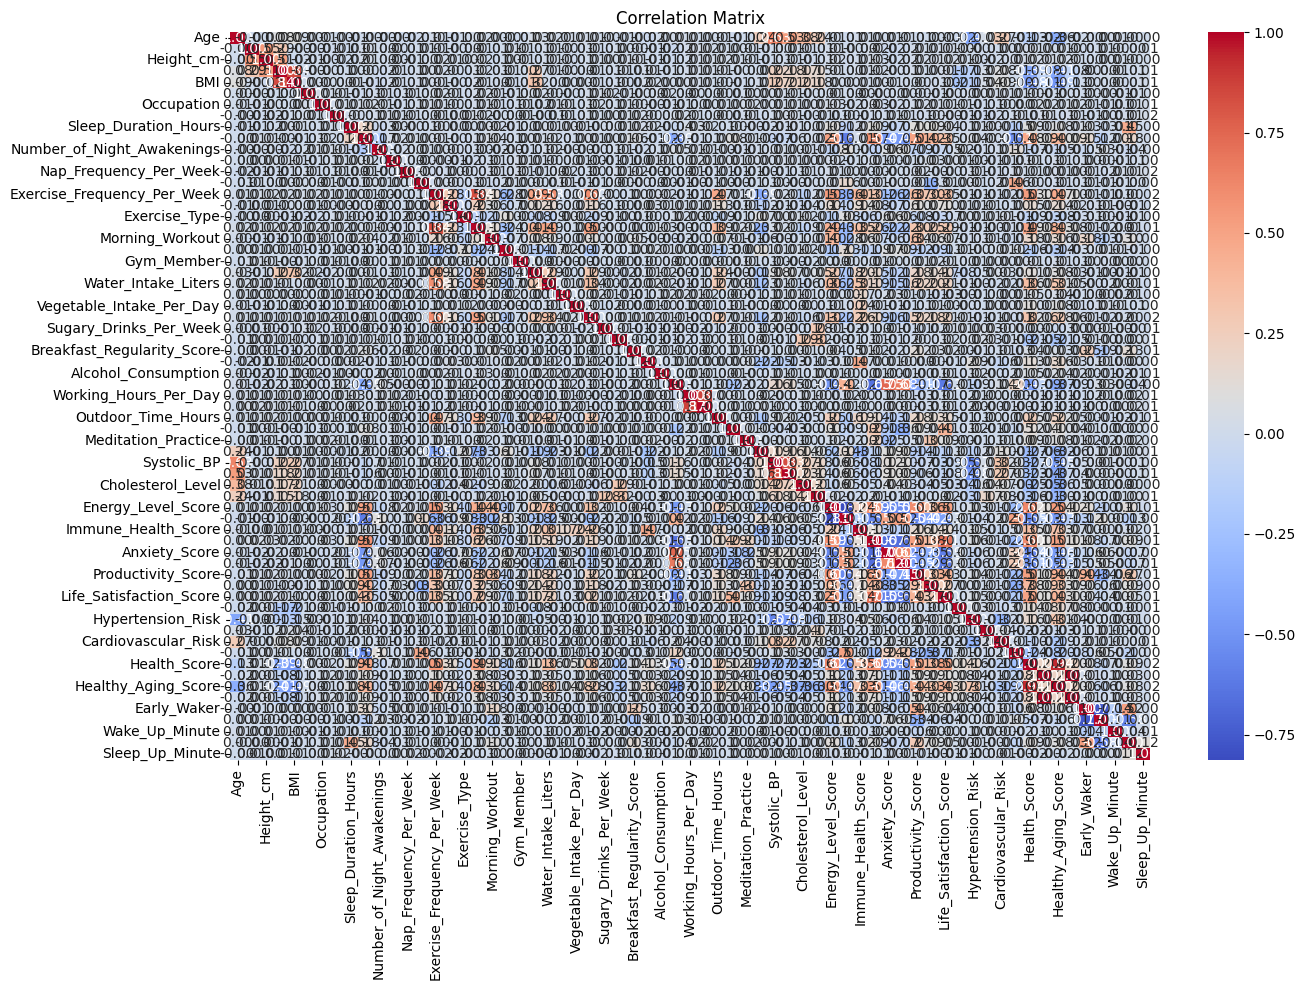

In [315]:
# EDA to visualization best of feature
corr = dfe.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

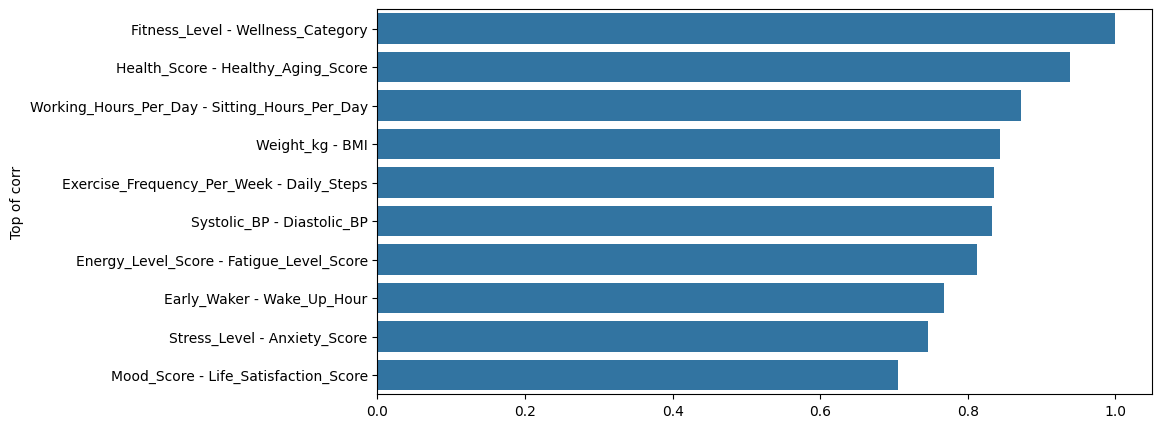

In [316]:
# Feature comparison visual data

corr_matrix = dfe.corr().abs()
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

top_corr = corr_pairs.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_corr.values, y=[f"{a} - {b}" for a,b in top_corr.index])
plt.ylabel("Top of corr")

plt.show()


In [317]:
X = dfe.drop(['Early_Waker'], axis=1)

y = dfe['Early_Waker']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, )

print("X Train size", len(y_train))
print("Y Test size", len(y_valid))


print("\nLabel test count data")
print(y_valid.value_counts())
print(X_train.shape)
print("Length of data", len(y_valid))

X Train size 7000
Y Test size 3000

Label test count data
Early_Waker
0.0    1758
1.0    1242
Name: count, dtype: int64
(7000, 64)
Length of data 3000


In [318]:
# Rebalancing data using SMOTEK
print(f"Data before balancing with smote {len(y_train)}")

smote = SMOTETomek()

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"The Data Size After Balancing With SMOTE {len(y_train_smote)}")

Data before balancing with smote 7000
The Data Size After Balancing With SMOTE 7298


Time predict : 0.9336502920014027 seconds


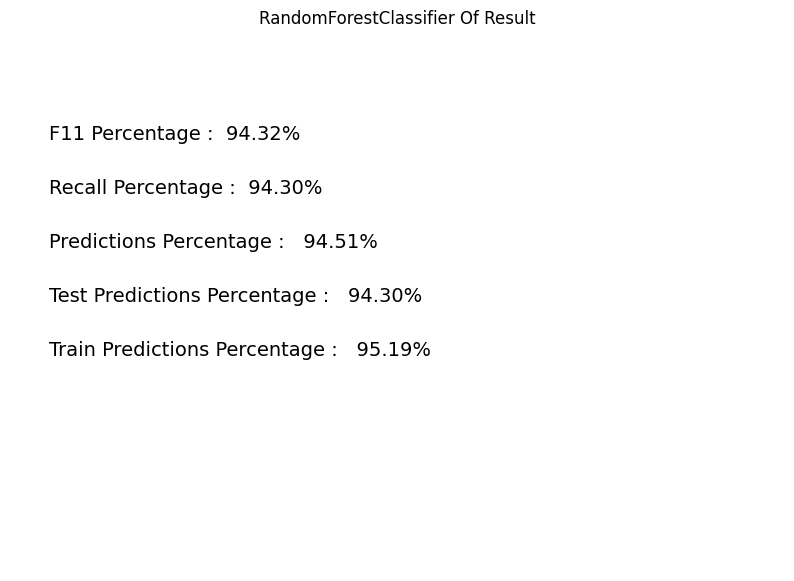

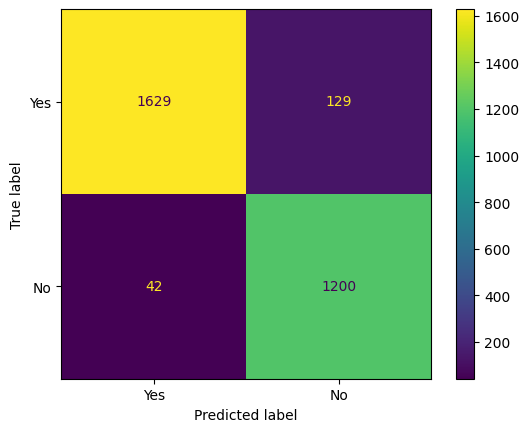


Calculating Learning Curve...


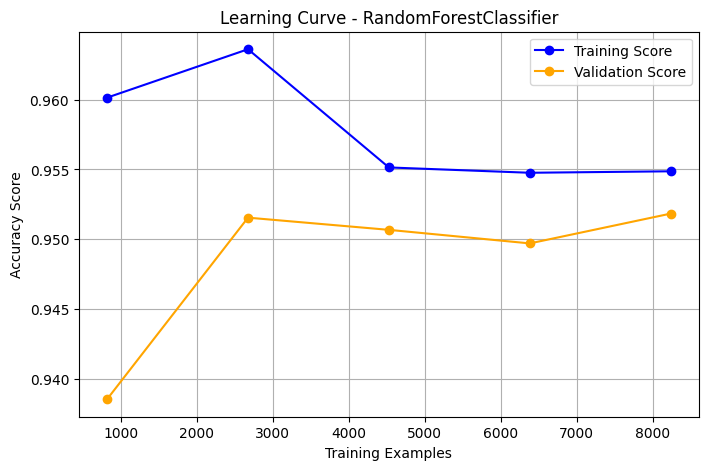

In [319]:
# Classification step using RandomForestClassifier

time_start = time.perf_counter()

model_rfc = RandomForestClassifier(    
    n_estimators=200,      
    max_depth=4,           
    min_samples_split=20,   
    min_samples_leaf=10,    
    random_state=42,
)

model_rfc.fit(X_train_smote, y_train_smote)

train_predictions = model_rfc.predict(X_train_smote)
test_predictions = model_rfc.predict(X_valid)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Precision = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("RandomForestClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes", "No"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5)

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


Time predict : 0.02832604099967284 seconds


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


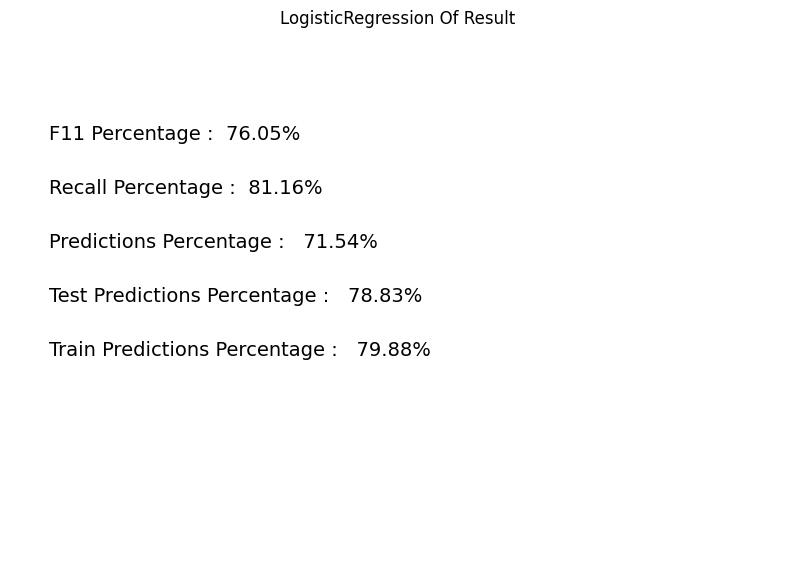

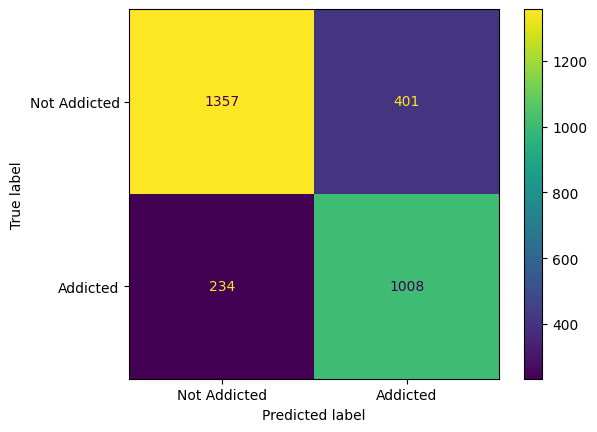


Calculating Learning Curve...


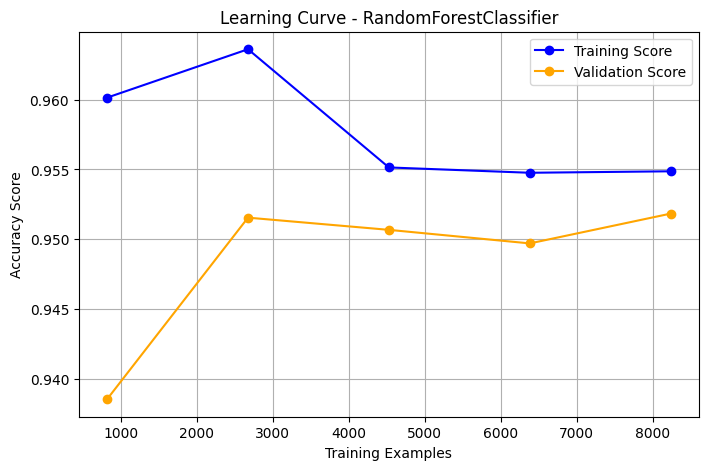

In [320]:
# Classifier using LogisticRegression

time_start = time.perf_counter()

model_lgr = LogisticRegression(    
    C=0.8,
    class_weight='balanced',  
    random_state=42
    )

model_lgr.fit(X_train_smote, y_train_smote)

train_predictions = model_lgr.predict(X_train_smote)
test_predictions = model_lgr.predict(X_valid)

# Evaluate
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions )
Predictions = precision_score(y_valid, test_predictions)
F11 = f1_score(y_valid, test_predictions)
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("LogisticRegression Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Predictions * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Addicted', 'Addicted']).plot()

plt.show()

print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5)

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()